In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("C:/Users/Likithasri/Downloads/archive (3)/raw_merged_heart_dataset.csv")
print(df.head())

   age  sex  cp trestbps chol fbs restecg thalachh exang  oldpeak slope ca  \
0   63    1   3      145  233   1       0      150     0      2.3     0  0   
1   37    1   2      130  250   0       1      187     0      3.5     0  0   
2   41    0   1      130  204   0       0      172     0      1.4     2  0   
3   56    1   1      120  236   0       1      178     0      0.8     2  0   
4   57    0   0      120  354   0       1      163     1      0.6     2  0   

  thal  target  
0    1       1  
1    2       1  
2    2       1  
3    2       1  
4    2       1  


In [3]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   object 
 4   chol      2181 non-null   object 
 5   fbs       2181 non-null   object 
 6   restecg   2181 non-null   object 
 7   thalachh  2181 non-null   object 
 8   exang     2181 non-null   object 
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   object 
 11  ca        2181 non-null   object 
 12  thal      2181 non-null   object 
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 238.7+ KB


In [5]:
df.describe()

,age,sex,cp,oldpeak,target
count,2181.000000,2181.000000,2181.000000,2181.000000,2181.000000
mean,53.477762,0.693260,1.248968,0.990509,0.496103
std,9.194787,0.461246,1.123520,1.141851,0.500099
min,28.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,1.000000,0.600000,0.000000
75%,60.000000,1.000000,2.000000,1.600000,1.000000
max,77.000000,1.000000,3.000000,6.200000,1.000000


Text(0.5, 1.0, 'histogram')

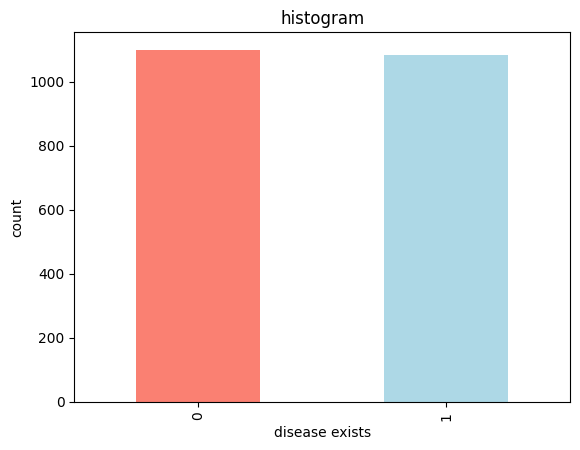

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
df.target.value_counts().plot(kind="bar",color=['salmon','lightblue'])
plt.xlabel("disease exists")
plt.ylabel("count")
plt.title("histogram")

In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
continous_val=[]
categorical_val=[]
for column in df.columns:
    print("===================================================")
    print(f"{column}: {df[column].unique()}")
    if len(df[column].unique())<10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

age: [63 37 41 56 57 44 52 54 48 49 64 58 50 66 43 69 59 42 61 40 71 51 65 53
 46 45 39 47 62 34 35 29 55 60 67 68 74 76 70 38 77 28 30 31 32 33 36]
sex: [1 0]
cp: [3 2 1 0]
trestbps: ['145' '130' '120' '140' '172' '150' '110' '135' '160' '105' '125' '142'
 '155' '104' '138' '128' '108' '134' '122' '115' '118' '100' '124' '94'
 '112' '102' '152' '101' '132' '148' '178' '129' '180' '136' '126' '106'
 '156' '170' '146' '117' '200' '165' '174' '192' '144' '123' '154' '114'
 '164' '98' '190' '?' '113' '92' '158']
chol: ['233' '250' '204' '236' '354' '192' '294' '263' '199' '168' '239' '275'
 '266' '211' '283' '219' '340' '226' '247' '234' '243' '302' '212' '175'
 '417' '197' '198' '177' '273' '213' '304' '232' '269' '360' '308' '245'
 '208' '264' '321' '325' '235' '257' '216' '256' '231' '141' '252' '201'
 '222' '260' '182' '303' '265' '309' '186' '203' '183' '220' '209' '258'
 '227' '261' '221' '205' '240' '318' '298' '564' '277' '214' '248' '255'
 '207' '223' '288' '160' '394' '315' '246

In [13]:
df.shape

(2181, 14)

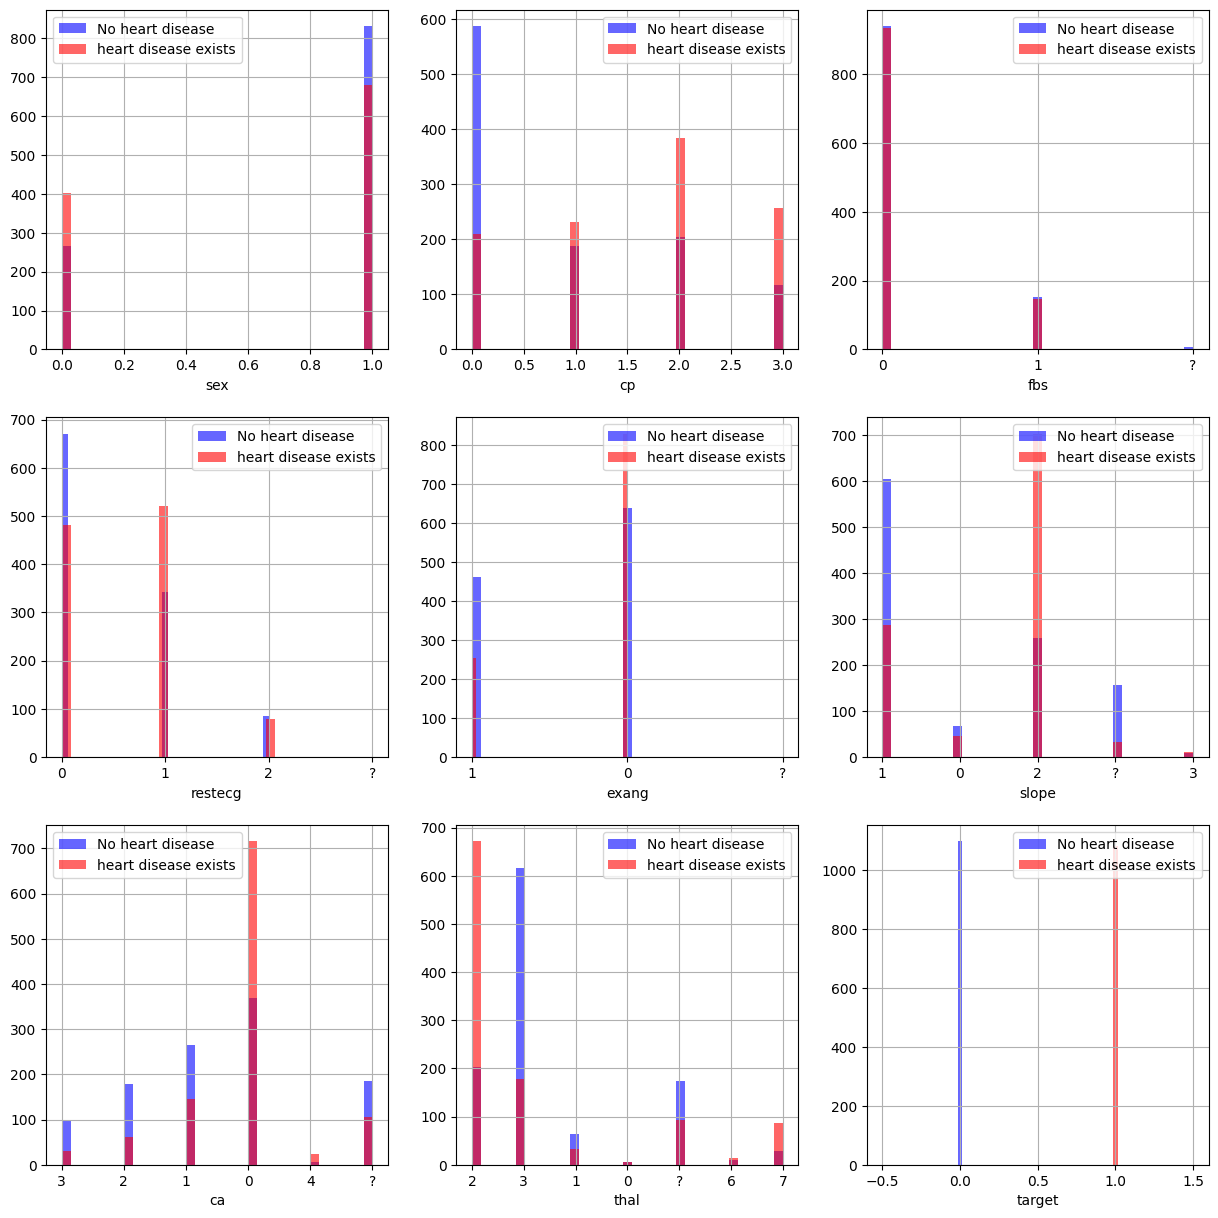

In [14]:
plt.figure(figsize=(15,15))
for i,column in enumerate(categorical_val,1):
    plt.subplot(3,3,i)
    df[df['target']==0][column].hist(bins=35,color='blue',label='No heart disease',alpha=0.6)
    df[df['target']==1][column].hist(bins=35,color='red',label='heart disease exists',alpha=0.6)
    plt.legend()
    plt.xlabel(column)

In [17]:
from sklearn.impute import SimpleImputer
df.replace('?',np.nan,inplace=True)

numeric_cols = ['age','trestbps','chol','thalachh','oldpeak']
categorical_val = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

# Numeric imputer
imputer_num = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer_num.fit_transform(df[numeric_cols])

# Categorical imputer
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_val] = imputer_cat.fit_transform(df[categorical_val])


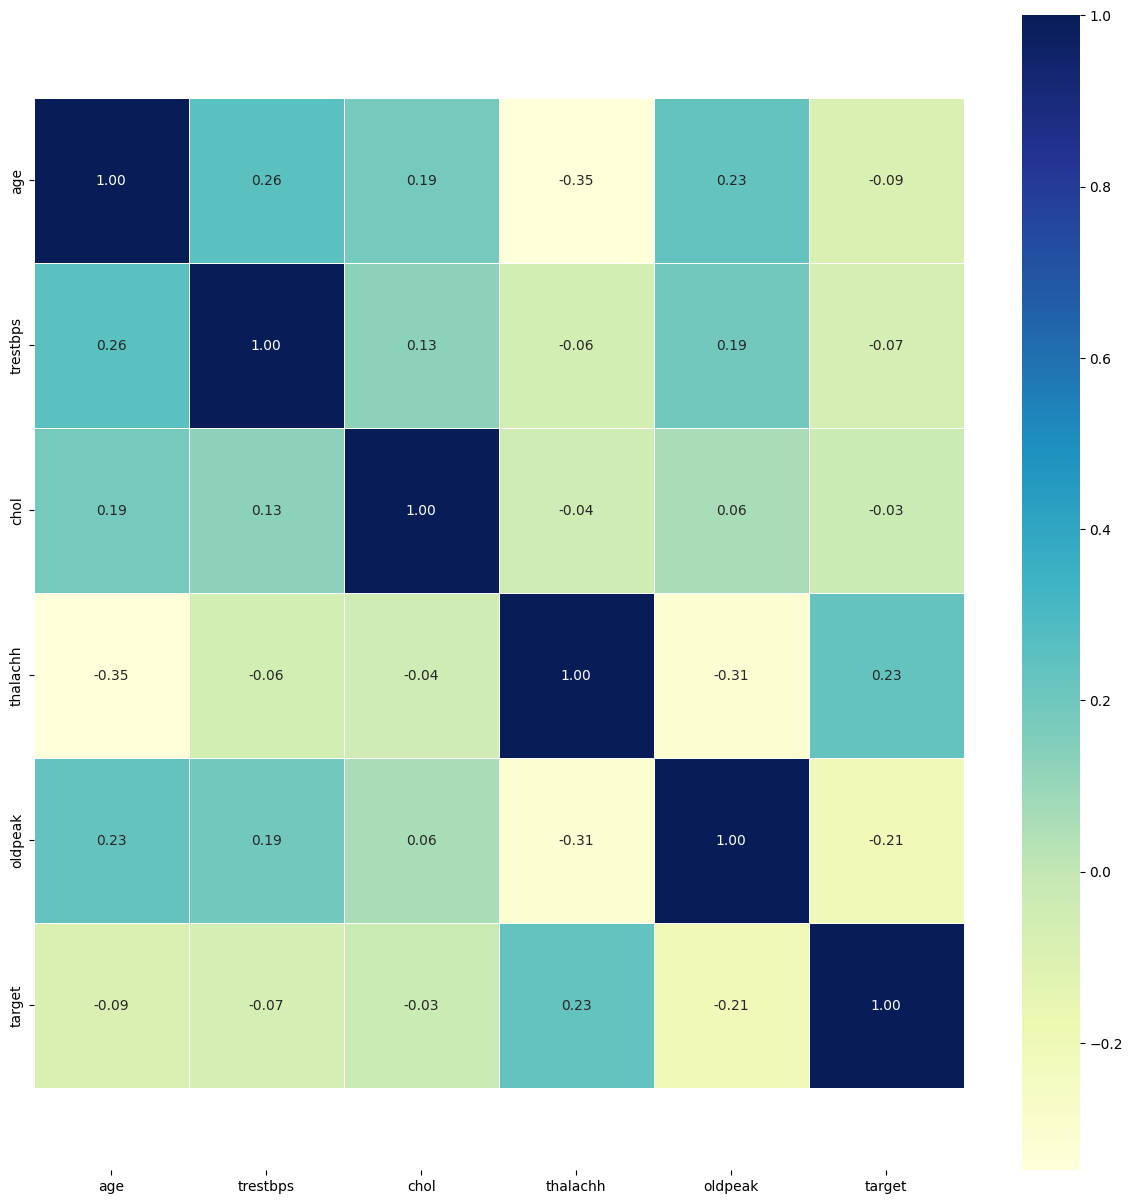

In [18]:


# Restrict to numeric columns only
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    linewidths=0.5,
    fmt=".2f",
    cmap='YlGnBu',
    ax=ax
)

# Fix ylim to avoid cut-off
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

plt.show()


In [19]:
print(categorical_val)

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [20]:
print(continous_val)

['age', 'trestbps', 'chol', 'thalachh', 'oldpeak']


In [31]:
# seperating the features
target_val = df['target']
independent_val = df.drop(columns=['target'])

In [32]:
type(independent_val)

pandas.core.frame.DataFrame

In [33]:
#one hot encoding (gummies)
independent_val = pd.get_dummies(independent_val, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])

In [34]:
independent_val.head()

,age,trestbps,chol,thalachh,oldpeak,sex_0,sex_1,cp_0,cp_1,cp_2,...,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3,thal_6,thal_7
0,1.035850,0.758664,-0.268045,0.083025,1.147078,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,-1.792487,-0.095676,0.049134,1.669950,2.198244,False,True,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,-1.357359,-0.095676,-0.809116,1.026602,0.358703,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,0.274375,-0.665235,-0.212072,1.283941,-0.166881,False,True,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,0.383157,-0.665235,1.989524,0.640593,-0.342075,True,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False


In [35]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [36]:
# data transformation
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [37]:
# scaling
numeric_cols=['age', 'trestbps', 'chol', 'thalachh', 'oldpeak']
df[numeric_cols]=sc.fit_transform(df[numeric_cols])

In [38]:
df[numeric_cols]

,age,trestbps,chol,thalachh,oldpeak
0,1.035850,0.758664,-0.268045,0.083025,1.147078
1,-1.792487,-0.095676,0.049134,1.669950,2.198244
2,-1.357359,-0.095676,-0.809116,1.026602,0.358703
3,0.274375,-0.665235,-0.212072,1.283941,-0.166881
4,0.383157,-0.665235,1.989524,0.640593,-0.342075
...,...,...,...,...,...
2176,0.709503,0.473884,-0.753143,-0.431653,0.796689
2177,-0.813448,0.473884,1.187248,-1.203670,0.709092
2178,0.600721,0.132148,-0.809116,0.597704,-0.166881
2179,0.056810,1.271267,-0.286703,0.683483,-0.867658


In [39]:
# training the data

from sklearn.model_selection import train_test_split
X=independent_val
y=target_val
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
# model traning
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(solver='liblinear')

In [41]:
def print_score(clf,X_train,y_train,X_test,y_test,train=True):
 if train:
    y_pred=clf.predict(X_train)
    clf_report=pd.DataFrame(classification_report(y_train,y_pred,output_dict=True))
    print("Train Results")
    print(f"Accuracy_score:{accuracy_score(y_train,y_pred)*100:.2f}%")
    print(f"confusion_matrix:{confusion_matrix(y_train, y_pred)}")
    print(f"classification_report:{classification_report(y_train,y_pred)}\n")
 elif train==False:
    y_pred=clf.predict(X_test)
    clf_report=pd.DataFrame(classification_report(y_test,y_pred,output_dict=True))
    print("Test Results")
    print(f"Accuracy_score:{accuracy_score(y_test,y_pred)*100:.2f}%")
    print(f"confusion_matrix:{confusion_matrix(y_test, y_pred)}")
    print(f"classification_report: {classification_report(y_test,y_pred)}\n")

In [42]:
# training the model
lr_clf=model.fit(X_train,y_train)
lr_clf

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [57]:
# model prediction 
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [44]:
print_score(lr_clf,X_train,y_train,X_test,y_test,train=True)
print_score(lr_clf,X_train,y_train,X_test,y_test,train=False)

Train Results
Accuracy_score:77.29%
confusion_matrix:[[657 225]
 [171 691]]
classification_report:              precision    recall  f1-score   support

           0       0.79      0.74      0.77       882
           1       0.75      0.80      0.78       862

    accuracy                           0.77      1744
   macro avg       0.77      0.77      0.77      1744
weighted avg       0.77      0.77      0.77      1744


Test Results
Accuracy_score:74.14%
confusion_matrix:[[148  69]
 [ 44 176]]
classification_report:               precision    recall  f1-score   support

           0       0.77      0.68      0.72       217
           1       0.72      0.80      0.76       220

    accuracy                           0.74       437
   macro avg       0.74      0.74      0.74       437
weighted avg       0.74      0.74      0.74       437




In [45]:
# SVC
from sklearn.svm import SVC
svc_clf=SVC()
svc_clf.fit(X_train,y_train)
print_score(svc_clf,X_train,y_train,X_test,y_test,train=True)
print_score(svc_clf,X_train,y_train,X_test,y_test,train=False)

Train Results
Accuracy_score:90.83%
confusion_matrix:[[777 105]
 [ 55 807]]
classification_report:              precision    recall  f1-score   support

           0       0.93      0.88      0.91       882
           1       0.88      0.94      0.91       862

    accuracy                           0.91      1744
   macro avg       0.91      0.91      0.91      1744
weighted avg       0.91      0.91      0.91      1744


Test Results
Accuracy_score:87.19%
confusion_matrix:[[183  34]
 [ 22 198]]
classification_report:               precision    recall  f1-score   support

           0       0.89      0.84      0.87       217
           1       0.85      0.90      0.88       220

    accuracy                           0.87       437
   macro avg       0.87      0.87      0.87       437
weighted avg       0.87      0.87      0.87       437




In [46]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C':[0.01,0.1,1,10], 'solver':['liblinear','lbfgs','saga']}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)


{'C': 0.1, 'solver': 'saga'} 0.7626222705266279


In [48]:
from sklearn.ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier()
rf_clf.fit(X_train,y_train)
print_score(rf_clf,X_train,y_train,X_test,y_test,train=True)
print_score(rf_clf,X_train,y_train,X_test,y_test,train=False)

Train Results
Accuracy_score:100.00%
confusion_matrix:[[882   0]
 [  0 862]]
classification_report:              precision    recall  f1-score   support

           0       1.00      1.00      1.00       882
           1       1.00      1.00      1.00       862

    accuracy                           1.00      1744
   macro avg       1.00      1.00      1.00      1744
weighted avg       1.00      1.00      1.00      1744


Test Results
Accuracy_score:94.51%
confusion_matrix:[[199  18]
 [  6 214]]
classification_report:               precision    recall  f1-score   support

           0       0.97      0.92      0.94       217
           1       0.92      0.97      0.95       220

    accuracy                           0.95       437
   macro avg       0.95      0.94      0.95       437
weighted avg       0.95      0.95      0.95       437




In [52]:
from sklearn.tree import DecisionTreeClassifier
dt_clf=DecisionTreeClassifier()
dt_clf.fit(X_train,y_train)
print_score(dt_clf,X_train,y_train,X_test,y_test,train=True)
print_score(dt_clf,X_train,y_train,X_test,y_test,train=False)

Train Results
Accuracy_score:100.00%
confusion_matrix:[[882   0]
 [  0 862]]
classification_report:              precision    recall  f1-score   support

           0       1.00      1.00      1.00       882
           1       1.00      1.00      1.00       862

    accuracy                           1.00      1744
   macro avg       1.00      1.00      1.00      1744
weighted avg       1.00      1.00      1.00      1744


Test Results
Accuracy_score:92.91%
confusion_matrix:[[196  21]
 [ 10 210]]
classification_report:               precision    recall  f1-score   support

           0       0.95      0.90      0.93       217
           1       0.91      0.95      0.93       220

    accuracy                           0.93       437
   macro avg       0.93      0.93      0.93       437
weighted avg       0.93      0.93      0.93       437




In [84]:
new=X_train.iloc[111]
a=np.asarray(new)
a=a.reshape(1,-1)
p=svc_clf.predict(a)
print(p[0])

0


In [85]:
if (p[0]==1):
    print("contains heart disease")
else:
    print("normal")

normal
